# 🎬 Sentiment Analysis on Movie Reviews

Goal is to analyze the sentiment of movie reviews using the Stanford Large Movie Review Dataset.
1. Download and extract the **Stanford Large Movie Review Dataset**.
2. Explore its structure (positive vs. negative reviews).
3. View a few sample reviews.
4. Collect basic statistics (counts, average review length).

In [1]:
# Step 1: Import Libraries

import os
import tarfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Step 2: Download the IMDb Dataset

url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
filename = "aclImdb_v1.tar.gz"

if not os.path.exists(filename):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, filename)

if not os.path.exists("aclImdb"):
    print("Extracting dataset...")
    with tarfile.open(filename, "r:gz") as tar:
        tar.extractall()

print("Dataset ready!")

Dataset ready!


## Step 3: Directory Structure

The dataset should now be extracted into a folder `aclImdb/` with:
- `train/pos` → positive training reviews
- `train/neg` → negative training reviews
- `test/pos` → positive testing reviews
- `test/neg` → negative testing reviews

In [3]:
# Step 3: Check Directories

try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

parent_dir = os.path.dirname(current_dir)
base_dir = os.path.join(parent_dir, "aclImdb")


# Define review directories
train_pos_dir = os.path.join(base_dir, "train", "pos")
train_neg_dir = os.path.join(base_dir, "train", "neg")
test_pos_dir = os.path.join(base_dir, "test", "pos")
test_neg_dir = os.path.join(base_dir, "test", "neg")

print("Train positive reviews:", len(os.listdir(train_pos_dir)))
print("Train negative reviews:", len(os.listdir(train_neg_dir)))
print("Test positive reviews:", len(os.listdir(test_pos_dir)))
print("Test negative reviews:", len(os.listdir(test_neg_dir)))

Train positive reviews: 12500
Train negative reviews: 12500
Test positive reviews: 12500
Test negative reviews: 12500


## Step 4: View Sample Reviews

Take one positive and one negative review and display the first 500 characters.

In [4]:
# Step 4: View Sample Reviews

pos_example = open(os.path.join(train_pos_dir, os.listdir(train_pos_dir)[0]), encoding="utf-8").read()
neg_example = open(os.path.join(train_neg_dir, os.listdir(train_neg_dir)[0]), encoding="utf-8").read()

print(" Positive Example:\n", pos_example[:500], "\n")
print(" Negative Example:\n", neg_example[:500], "\n")

 Positive Example:
 For a movie that gets no respect there sure are a lot of memorable quotes listed for this gem. Imagine a movie where Joe Piscopo is actually funny! Maureen Stapleton is a scene stealer. The Moroni character is an absolute scream. Watch for Alan "The Skipper" Hale jr. as a police Sgt. 

 Negative Example:
 Working with one of the best Shakespeare sources, this film manages to be creditable to it's source, whilst still appealing to a wider audience.<br /><br />Branagh steals the film from under Fishburne's nose, and there's a talented cast on good form. 



## Step 5: Basic Statistics

Measure:
- Average review length
- Distribution of lengths

Average length (positive reviews): 236.268
Average length (negative reviews): 234.42


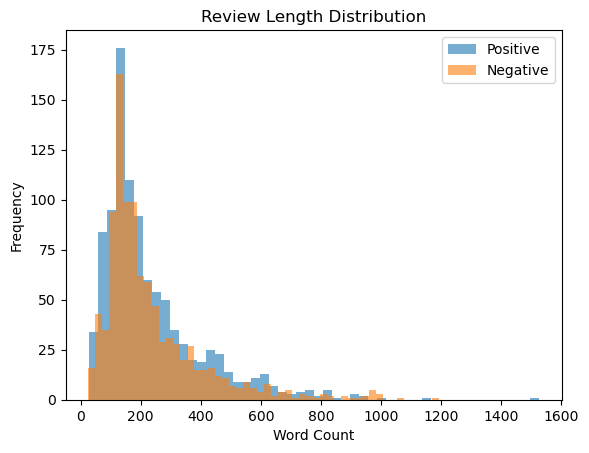

In [10]:
# Step 5: Basic Statistics

lengths_pos = [len(open(os.path.join(train_pos_dir, f), encoding="utf-8").read().split()) 
               for f in os.listdir(train_pos_dir)[:1000]]  # sample 1000 reviews
lengths_neg = [len(open(os.path.join(train_neg_dir, f), encoding="utf-8").read().split()) 
               for f in os.listdir(train_neg_dir)[:1000]]

print("Average length (positive reviews):", np.mean(lengths_pos))
print("Average length (negative reviews):", np.mean(lengths_neg))

# Plot distribution
plt.hist(lengths_pos, bins=50, alpha=0.6, label="Positive")
plt.hist(lengths_neg, bins=50, alpha=0.6, label="Negative")
plt.legend()
plt.title("Review Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()